In [1]:
# ------------------------------------------
# STEP 1 :- Import Libraries & Load Data
# ------------------------------------------


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("student.csv")

# View data
df.head()

,Student_ID,Gender,Age,Study_Hours_per_Week,Attendance_Percentage,Previous_Grade,Internet_Usage_Hours,Final_Score,Result
0,1,Male,23,14,67,80,4,32.73,Fail
1,2,Female,24,34,98,51,8,46.08,Fail
2,3,Male,18,29,77,88,7,49.32,Fail
3,4,Male,18,24,96,54,9,44.09,Fail
4,5,Male,18,9,60,70,5,31.05,Fail


In [2]:
# -----------------------------------------
# STEP 2 :- Data Understanding
# ------------------------------------------

# Basic info
print(df.info())

# Statistical summary
print(df.describe())

# Check missing values
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             1000 non-null   int64  
 1   Gender                 1000 non-null   object 
 2   Age                    1000 non-null   int64  
 3   Study_Hours_per_Week   1000 non-null   int64  
 4   Attendance_Percentage  1000 non-null   int64  
 5   Previous_Grade         1000 non-null   int64  
 6   Internet_Usage_Hours   1000 non-null   int64  
 7   Final_Score            1000 non-null   float64
 8   Result                 1000 non-null   object 
dtypes: float64(1), int64(6), object(2)
memory usage: 70.4+ KB
None
        Student_ID          Age  Study_Hours_per_Week  Attendance_Percentage  \
count  1000.000000  1000.000000           1000.000000            1000.000000   
mean    500.500000    21.005000             22.062000              74.784000   
std     288.819

In [3]:
# -----------------------------------------
# STEP 3 :- Data Preparation
# ------------------------------------------

# Convert categorical to numeric

# Gender encoding
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

# Result encoding
df['Result'] = df['Result'].map({'Fail': 0, 'Pass': 1})

# Drop unnecessary column
df = df.drop('Student_ID', axis=1)

df.head()

,Gender,Age,Study_Hours_per_Week,Attendance_Percentage,Previous_Grade,Internet_Usage_Hours,Final_Score,Result
0,0,23,14,67,80,4,32.73,0
1,1,24,34,98,51,8,46.08,0
2,0,18,29,77,88,7,49.32,0
3,0,18,24,96,54,9,44.09,0
4,0,18,9,60,70,5,31.05,0


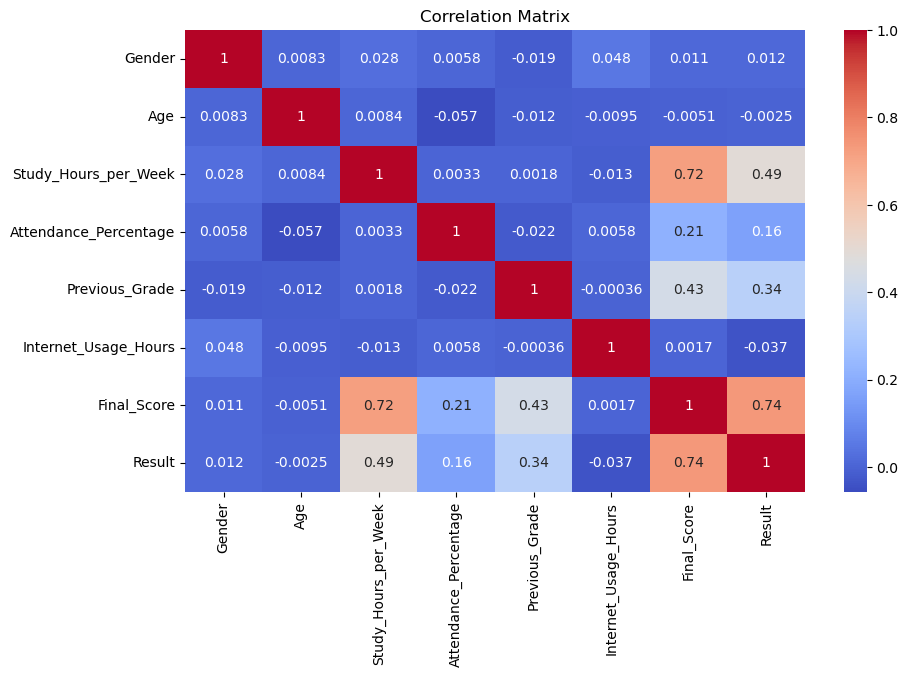

In [4]:
# -----------------------------------------
# STEP 4 :- Exploratory Data Analysis (EDA)
# ------------------------------------------

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

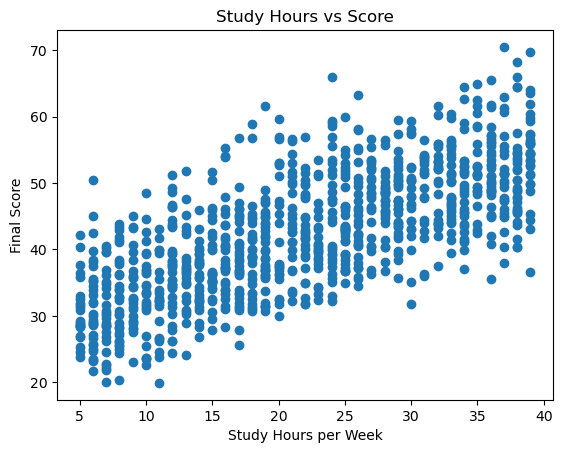

In [5]:
# Study Hours vs Final Score

plt.scatter(df['Study_Hours_per_Week'], df['Final_Score'])
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Score")
plt.title("Study Hours vs Score")
plt.show()

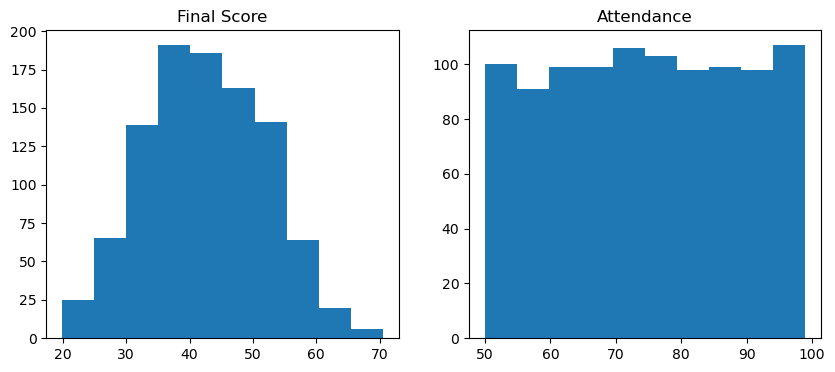

In [10]:
# Attendance vs Final Score

plt.figure(figsize=(10,4))

# Final Score Histogram
plt.subplot(1,2,1)
plt.hist(df['Final_Score'], bins=10)
plt.title("Final Score")

# Attendance Histogram
plt.subplot(1,2,2)
plt.hist(df['Attendance_Percentage'], bins=10)
plt.title("Attendance")

plt.show()

In [11]:
# -----------------------------------------
# STEP 5 :- Modeling (Regression)
# ------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features & target
X = df[['Study_Hours_per_Week', 'Attendance_Percentage', 'Previous_Grade', 'Internet_Usage_Hours']]
y = df['Final_Score']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [12]:
# -----------------------------------------
# STEP 6 :- Evaluation
# ------------------------------------------

from sklearn.metrics import mean_squared_error, r2_score

# Prediction
y_pred = model.predict(X_test)

# Metrics
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 18.11041640206075
R2 Score: 0.7631761906130123


In [17]:
# -----------------------------------------
# STEP 7 :- Classification Model (Pass/Fail)
# ------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Target
y_class = df['Result']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2)

# Model
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Prediction
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9


In [19]:
# -----------------------------------------
# STEP 8 :- Deployment (Simple Prediction Example)
# ------------------------------------------

# Example input: [Study Hours, Attendance, Previous Grade, Internet Usage]
new_data = [[10, 85, 75, 5]]

prediction = model.predict(new_data)
print("Predicted Score:", prediction[0])

Predicted Score: 38.12587496784552


C:\Users\DHRUV\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
